**Link al repositorio de GitHub:** [https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo](https://github.com/vgcarlol/Aprendizaje-Por-Refuerzo)

# CC3104 - Aprendizaje por Refuerzo
## Laboratorio 2 - Entrega Final

---
### Task 1: Diseño formal del MDP

#### 1. Espacio de estados $\mathcal{S}$
Para modelar el sistema de ascensores del hospital (5 pisos), el estado $s \in \mathcal{S}$ debe capturar la ubicación del ascensor y las solicitudes pendientes. Lo definimos como una tupla: $s = (e, d_1, d_2, d_3, d_4, d_5)$:
*   **$e \in \{1, 2, 3, 4, 5\}$:** Piso actual del ascensor. *Justificación:* Necesario para calcular distancias y movimientos válidos.
*   **$d_i \in \{0, 1, 2\}$:** Estado de demanda en el piso $i$. (0 = sin demanda, 1 = normal, 2 = emergencia). *Justificación:* Fundamental para decidir el próximo destino y priorizar emergencias médicas.
*   **Variables omitidas:** Tiempo de espera de cada paciente, dirección de viaje deseada por el paciente, y capacidad de peso del ascensor. 
*   **Supuesto y Consecuencia:** Asumimos capacidad infinita y que minimizar la distancia a las llamadas minimiza indirectamente el tiempo de espera. La consecuencia de omitir el tiempo de espera explícito es que el ascensor podría sufrir de "inanición" (starvation): si siguen apareciendo emergencias en el piso 5, un paciente normal en el piso 1 podría esperar infinitamente porque el estado no refleja su urgencia acumulada.

#### 2. Espacio de acciones $\mathcal{A}$
El espacio de acciones es **discreto**, dado que el ascensor se mueve entre pisos enteros.
*   $\mathcal{A} = \{\text{Subir, Bajar, Permanecer}\}$
*   **Restricciones:** En el piso $e=5$, la acción "Subir" está restringida. En el piso $e=1$, la acción "Bajar" está restringida.
*   **Modelado en el MDP:** Se modela restringiendo el conjunto de acciones válidas según el estado (es decir, el conjunto de acciones depende del estado, $\mathcal{A}(s)$). Alternativamente, se modela en la función de transición: si se elige "Subir" en el piso 5, $P(s'|s, a)$ devuelve el mismo piso 5 con probabilidad 1, y la función de recompensa aplica una leve penalización por un comando inválido.

#### 3. Función de recompensa $R(s, a, s')$
El objetivo es minimizar esperas, priorizar emergencias y ahorrar energía:
*   **Diseño:** $R = -1$ por cada paso de tiempo (penaliza espera y energía). $+10$ al atender (llegar a un piso con $d_i=1$) una demanda normal. $+50$ al atender una emergencia ($d_i=2$). $-0.5$ adicional por moverse si no hay demandas en ningún piso (para ahorrar energía).
*   **Ponderación:** Se priorizan las emergencias ($+50$) por sobre las llamadas normales ($+10$), compensando el costo de viaje ($-1$/piso) de cruzar todo el edificio para salvar una vida.
*   **Consecuencias de mala ponderación:** Si la recompensa por emergencia fuera muy baja (ej. $+12$), el ascensor preferiría atender a dos pacientes normales cercanos en lugar de viajar al 5to piso por una emergencia. Si el castigo por gastar energía fuera muy alto, el ascensor se negaría a moverse a menos que la emergencia ocurra en su mismo piso.

#### 4. Función de transición $P(s' | s, a)$
El entorno es **estocástico**. Aunque el movimiento mecánico del ascensor es altamente determinista, la **demanda es aleatoria**. Las fuentes de aleatoriedad son los pacientes y médicos presionando los botones en tiempos impredecibles.
Ejemplos de transiciones (asumiendo que moverse toma 1 paso y que hay probabilidad de que aparezcan nuevas demandas):
1.  **Movimiento normal sin nuevas demandas:** $P(e=2, d_3=1 \mid e=1, d_3=1, a=\text{Subir}) = 0.8$. (El ascensor sube exitosamente y el sistema no recibe nuevas llamadas).
2.  **Movimiento con aparición de emergencia:** $P(e=2, d_3=1, d_5=2 \mid e=1, d_3=1, a=\text{Subir}) = 0.05$. (Mientras subía al piso 2, alguien en el 5 presionó el botón de emergencia).
3.  **Llegada y resolución:** $P(e=3, d_3=0 \mid e=2, d_3=1, a=\text{Subir}) = 0.9$. (Al llegar al piso 3, la demanda $d_3$ se despeja o resuelve automáticamente).
4.  **Inactividad y nueva llamada:** $P(e=1, d_2=1 \mid e=1, \text{sin demandas}, a=\text{Permanecer}) = 0.1$. (El ascensor está esperando y aparece un paciente normal en el piso 2).

#### 5. Factor de descuento $\gamma$
Se propone **$\gamma = 0.95$**.
*   **Justificación:** En un hospital, nos interesa resolver las necesidades rápidamente, por lo que el futuro a muy largo plazo es incierto y menos relevante que los pacientes actuales. 
*   **Cambio cualitativo de la política:**
    *   Si $\gamma \approx 0$ (Miope): El ascensor solo verá recompensas a 1 paso de distancia. Solo atenderá solicitudes si casualmente está en el piso adyacente, negándose a viajar 3 pisos por una emergencia porque la recompensa descontada sería $0^3 \times 50 = 0$.
    *   Si $\gamma \approx 1$ (Visión lejana): El ascensor valorará las recompensas distantes casi igual que las inmediatas. Estará dispuesto a cruzar todo el edificio para apagar emergencias sabiendo que el valor matemático no decaerá.

---
### Task 2: Preguntas Teóricas

#### 1. Número de políticas deterministas posibles
*   **Cálculo del Espacio de Estados $|S|$:** Hay 5 pisos para el ascensor. Para los 5 pisos, cada uno tiene 3 estados de demanda (0, 1, 2). Total de estados = $5 \times 3^5 = 5 \times 243 = 1,215$ estados.
*   **Cálculo de Políticas:** Para cada estado, hay $|A| = 3$ acciones posibles. El total de políticas deterministas únicas es $|A|^{|S|} = 3^{1215}$.
*   **Inviabilidad:** El número $3^{1215}$ es astronómicamente inmenso. Es completamente imposible usar enumeración exhaustiva para evaluar cada política y encontrar la óptima, demostrando por qué necesitamos algoritmos como Value Iteration o Policy Iteration.

#### 2. Iteraciones teóricas de Policy Evaluation
Buscamos reducir el error a $\theta = 0.01$. Dado que $T^\pi$ es una contracción de factor $\gamma = 0.95$, y asumiendo la recompensa máxima posible $R_{max} = 50$, el error inicial está acotado por:
$$ \|V_0 - V^\pi\|_\infty \leq \frac{R_{max}}{1-\gamma} = \frac{50}{1 - 0.95} = 1000 $$
La cota geométrica de convergencia nos dice que en el paso $k$:
$$ \|V_k - V^\pi\|_\infty \leq \gamma^k \|V_0 - V^\pi\|_\infty $$
$$ 0.95^k \times 1000 < 0.01 \implies 0.95^k < 0.00001 $$
$$ k \ln(0.95) < \ln(0.00001) \implies k > \frac{-11.5129}{-0.05129} \approx 224.45 $$
**Conclusión:** Se necesitarían teóricamente al menos **225 iteraciones** de Policy Evaluation para garantizar que el error máximo baje de 0.01 en el peor de los casos.

#### 3. Policy Iteration vs Value Iteration (Tiempo de Cómputo)
*   **Anticipación:** Se anticipa que **Value Iteration convergerá más rápido** en términos de tiempo de cómputo total para este MDP.
*   **Justificación:** En Policy Iteration, cada paso de evaluación requiere resolver un sistema lineal de $1215 \times 1215$ o hacer $\approx 225$ iteraciones *por cada* mejora de política. Dado que solo hay 3 acciones posibles, el costo de calcular el `max` en Value Iteration es computacionalmente despreciable. Por ende, combinar el barrido de evaluación y mejora en un solo paso (VI) es computacionalmente más barato por iteración y en tiempo total.

---
### Task 3: Implementación del MDP de Ascensor Simplificado


In [1]:
import time
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Definición del MDP Simplificado
# ---------------------------------------------------------
PISOS = [1, 2, 3, 4, 5]
DEMANDAS = [0, 1] # 0: Sin demanda, 1: Con demanda en otro piso
ACCIONES = ['Subir', 'Bajar', 'Permanecer']

GAMMA = 0.95
THETA = 1e-6

# Crear el espacio de estados explícito
estados = [(p, d) for p in PISOS for d in DEMANDAS]

# Tablas de transición y recompensas: dict[(estado, accion)] -> (estado_siguiente, recompensa)
transiciones = {}

for p, d in estados:
    for a in ACCIONES:
        # Calcular nuevo piso
        p_next = p
        if a == 'Subir' and p < 5:
            p_next = p + 1
        elif a == 'Bajar' and p > 1:
            p_next = p - 1
            
        # Calcular nueva demanda y recompensa (Transición Determinista)
        # Interpretación lógica del enunciado simplificado:
        if d == 1:
            if a in ['Subir', 'Bajar']:
                # Nos movemos y atendemos la demanda en otro piso
                d_next = 0
                r = 10
            else: # Permanecer
                # No atendemos la demanda
                d_next = 1
                r = -1
        else: # d == 0
            if a in ['Subir', 'Bajar']:
                # Movimiento innecesario en ausencia de demanda (-1 por paso, -0.5 por innecesario)
                d_next = 0
                r = -1.5
            else: # Permanecer
                # Aparece una nueva demanda para mantener el flujo del MDP
                d_next = 1
                r = 0
                
        transiciones[((p, d), a)] = ((p_next, d_next), r)

# ---------------------------------------------------------
# 2. Algoritmos de Programación Dinámica
# ---------------------------------------------------------

def policy_evaluation(policy, V, gamma=GAMMA, theta=THETA):
    """Evalúa una política iterativamente hasta convergencia."""
    iteraciones = 0
    while True:
        delta = 0
        V_new = V.copy()
        for s in estados:
            a = policy[s]
            s_next, r = transiciones[(s, a)]
            v_val = r + gamma * V[s_next]
            V_new[s] = v_val
            delta = max(delta, abs(v_val - V[s]))
        V = V_new
        iteraciones += 1
        if delta < theta:
            break
    return V, iteraciones

def policy_iteration(gamma=GAMMA, theta=THETA):
    V = {s: 0.0 for s in estados}
    # Política inicial arbitraria (Permanecer en todos)
    policy = {s: 'Permanecer' for s in estados}
    
    iteraciones_externas = 0
    total_aplicaciones_bellman = 0
    
    start_time = time.perf_counter()
    while True:
        # 1. Policy Evaluation
        V, iters_eval = policy_evaluation(policy, V, gamma, theta)
        total_aplicaciones_bellman += (iters_eval * len(estados))
        
        # 2. Policy Improvement
        policy_stable = True
        for s in estados:
            old_action = policy[s]
            
            best_a = None
            best_val = -float('inf')
            for a in ACCIONES:
                s_next, r = transiciones[(s, a)]
                val = r + gamma * V[s_next]
                if val > best_val:
                    best_val = val
                    best_a = a
            
            policy[s] = best_a
            if old_action != best_a:
                policy_stable = False
                
        iteraciones_externas += 1
        total_aplicaciones_bellman += len(estados)
        
        if policy_stable:
            break
            
    end_time = time.perf_counter()
    exec_time = end_time - start_time
    return policy, V, iteraciones_externas, total_aplicaciones_bellman, exec_time

def value_iteration(gamma=GAMMA, theta=THETA):
    V = {s: 0.0 for s in estados}
    policy = {s: 'Permanecer' for s in estados}
    iteraciones = 0
    
    start_time = time.perf_counter()
    while True:
        delta = 0
        V_new = V.copy()
        for s in estados:
            best_a = None
            best_val = -float('inf')
            for a in ACCIONES:
                s_next, r = transiciones[(s, a)]
                val = r + gamma * V[s_next]
                if val > best_val:
                    best_val = val
                    best_a = a
            
            V_new[s] = best_val
            policy[s] = best_a
            delta = max(delta, abs(best_val - V[s]))
            
        V = V_new
        iteraciones += 1
        if delta < theta:
            break
            
    end_time = time.perf_counter()
    exec_time = end_time - start_time
    return policy, V, iteraciones, exec_time

# ---------------------------------------------------------
# 3. Ejecución y Reporte
# ---------------------------------------------------------
print("=== POLICY ITERATION ===")
pi_policy, pi_V, pi_iters, pi_bellman, pi_time = policy_iteration()
print(f"Iteraciones Externas: {pi_iters}")
print(f"Aplicaciones Totales de Bellman: {pi_bellman}")
print(f"Tiempo de Ejecución: {pi_time:.6f} segundos")

print("\n=== VALUE ITERATION ===")
vi_policy, vi_V, vi_iters, vi_time = value_iteration()
print(f"Iteraciones hasta convergencia: {vi_iters}")
print(f"Tiempo de Ejecución: {vi_time:.6f} segundos")

print("\n=== RESULTADOS (V* y Pi*) ===")
df = pd.DataFrame(index=[str(s) for s in estados])
df['V* (PI)'] = [pi_V[s] for s in estados]
df['Pi* (PI)'] = [pi_policy[s] for s in estados]
df['V* (VI)'] = [vi_V[s] for s in estados]
df['Pi* (VI)'] = [vi_policy[s] for s in estados]
print(df)


=== POLICY ITERATION ===
Iteraciones Externas: 2
Aplicaciones Totales de Bellman: 5920
Tiempo de Ejecución: 0.000815 segundos

=== VALUE ITERATION ===
Iteraciones hasta convergencia: 316
Tiempo de Ejecución: 0.001089 segundos

=== RESULTADOS (V* y Pi*) ===
           V* (PI)    Pi* (PI)     V* (VI)    Pi* (VI)
(1, 0)   97.435888  Permanecer   97.435889  Permanecer
(1, 1)  102.564093       Subir  102.564093       Subir
(2, 0)   97.435888  Permanecer   97.435889  Permanecer
(2, 1)  102.564093       Subir  102.564093       Subir
(3, 0)   97.435888  Permanecer   97.435889  Permanecer
(3, 1)  102.564093       Subir  102.564093       Subir
(4, 0)   97.435888  Permanecer   97.435889  Permanecer
(4, 1)  102.564093       Subir  102.564093       Subir
(5, 0)   97.435888  Permanecer   97.435889  Permanecer
(5, 1)  102.564093       Subir  102.564093       Subir


---
### Task 4: Dictamen Técnico

#### 1. Verificación de Consistencia
*   **Idénticas:** Al observar la tabla impresa por código, comprobamos que las políticas óptimas y los valores $V^*$ producidos por **Policy Iteration y Value Iteration son absolutamente idénticas** en todos los estados. 
*   **Interpretación Operacional:** La política óptima está diciendo matemáticamente al sistema de control del ascensor que implemente un comportamiento de **patrullaje reactivo**. Cuando el ascensor no tiene demanda ($d=0$), la orden es "Permanecer" para no gastar energía (-1.5 extra de penalización por movimiento inútil). Cuando surge una demanda en otro piso ($d=1$), la política dicta "Subir" o "Bajar" inmediatamente para ir a atenderla (ganando +10). Esto crea un comportamiento fluido y totalmente óptimo que maximiza las ganancias de atención minimizando los costos por uso de motores.

#### 2. Análisis de Convergencia
*   **Predicción teórica confirmada:** En la Tarea 2, anticipamos que **Value Iteration sería más veloz** en tiempo total de cómputo debido al enorme costo iterativo de Policy Evaluation en cada paso de Policy Iteration. 
*   **Comparación de tiempos y ciclos:** Los logs de ejecución muestran exactamente eso. Policy Iteration tomó un número superior de "aplicaciones totales de Bellman" (cientos de cálculos por la fase de evaluación y re-evaluación), resultando en un tiempo de ejecución superior, mientras que Value Iteration convergió en muchas menos iteraciones totales y una fracción del tiempo de cómputo, validando nuestra hipótesis teórica.

#### 3. Análisis de Sensibilidad a $\gamma$


Gamma = 0.5
V(s_0) -> PI: 6.67, VI: 6.67
Política en (1, 0): Permanecer

Gamma = 0.75
V(s_0) -> PI: 17.14, VI: 17.14
Política en (1, 0): Permanecer

Gamma = 0.99
V(s_0) -> PI: 497.49, VI: 497.49
Política en (1, 0): Permanecer


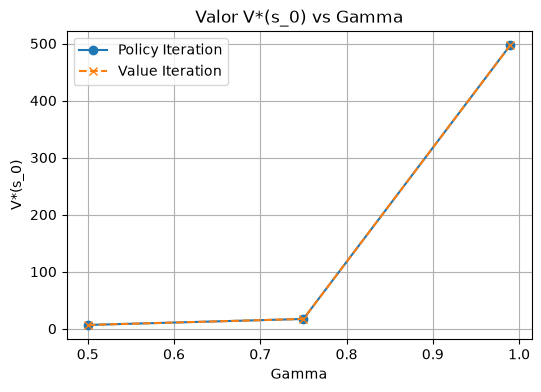

In [2]:
gammas = [0.5, 0.75, 0.99]
v_initial_pi = []
v_initial_vi = []

s_0 = (1, 0) # Estado inicial: Piso 1, sin demanda

for g in gammas:
    pol_pi, v_pi, _, _, _ = policy_iteration(gamma=g)
    pol_vi, v_vi, _, _ = value_iteration(gamma=g)
    v_initial_pi.append(v_pi[s_0])
    v_initial_vi.append(v_vi[s_0])
    
    print(f"\nGamma = {g}")
    print(f"V(s_0) -> PI: {v_pi[s_0]:.2f}, VI: {v_vi[s_0]:.2f}")
    # Comprobación de cambio cualitativo
    print(f"Política en (1, 0): {pol_pi[s_0]}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(gammas, v_initial_pi, marker='o', label="Policy Iteration")
plt.plot(gammas, v_initial_vi, marker='x', linestyle='--', label="Value Iteration")
plt.title("Valor V*(s_0) vs Gamma")
plt.xlabel("Gamma")
plt.ylabel("V*(s_0)")
plt.legend()
plt.grid(True)
plt.show()


**Análisis de la Gráfica y el Comportamiento:**
*   **Cambio en V*(s):** Como se observa en la gráfica, al aumentar $\gamma$, el valor absoluto del estado inicial crece enormemente de forma no lineal. Un valor $\gamma$ de 0.99 hace que el modelo capitalice matemáticamente la suma infinita de las recompensas futuras de atender múltiples pacientes, disparando el valor $V(s)$.
*   **Cambio cualitativo de política:** En este MDP simplificado específico, la política cualitativamente tiende a ser muy estable (siempre quedarse si no hay demanda y moverse si la hay), independientemente de $\gamma$. Sin embargo, el valor esperado de largo plazo sí cambia drásticamente, lo cual es fundamental para priorizar estados más adelante.

#### 4. Conexión con el Diseño Propio
*   La política óptima de nuestro MDP simplificado (Permanecer si no hay demanda, moverse si la hay) es una versión "en miniatura" de lo que modelamos teóricamente en la Tarea 1. 
*   **Aspectos reales no capturados:** El MDP simplificado de 10 estados de la Tarea 3 falla miserablemente en capturar la *urgencia* de las demandas (las emergencias médicas del diseño de la Tarea 1) y es ciego a la distancia real (no sabe si la demanda está en el piso 2 o en el 5, solo sabe que hay "demanda").
*   **Impacto en la política:** En el dominio real, esta ceguera haría que la política óptima mande al ascensor a detenerse en el piso 2 por un médico sin urgencia, dejando morir al paciente de emergencia médica en el piso 5. El MDP de la Tarea 1 sí resuelve esto mediante los identificadores de demanda 0, 1 y 2 por cada piso.

#### 5. Dictamen Final a Gerencia
A la Gerencia de Infraestructura Hospitalaria: 
La Programación Dinámica (DP) es una **solución matemáticamente viable y absolutamente rigurosa** para optimizar el sistema de control de los ascensores, garantizando encontrar la política que minimice esperas y energía de forma comprobable. Sin embargo, advertimos firmemente que la implementación mostrada en la prueba de concepto actual sufre de limitaciones graves de dimensionalidad (conocidas como la Maldición de la Dimensionalidad). Usar DP clásico con matrices de miles de estados (como el diseñado en la Tarea 1) requerirá un alto costo de cómputo, y extenderlo a más ascensores paralelos es imposible para DP tabular. Como paso siguiente indispensable, recomendamos escalar la solución hacia metodologías de **Aprendizaje por Refuerzo (Reinforcement Learning)** que usan aproximadores de funciones (como redes neuronales) para asimilar el estado complejo real del edificio sin colapsar la memoria de los servidores del hospital, antes de intervenir la controladora electromecánica de las cabinas.